In [4]:
# problem 1
import numpy as np
from scipy.linalg import eig
# define PageRank matrix M
# M[i, j] ：the probability of moving from page j to page i
M = np.array([
    [0.0,   0.0,  0.5, 0.0],
    [1/3,   0.0,  0.0, 0.5],
    [1/3,  0.5,  0.0, 0.5],
    [1/3,  0.5,  0.5, 0.0]
], dtype=float)

print("Matrix M:\n", M)
print("Column sums (should all be 1 for a stochastic matrix):")
print(M.sum(axis=0))


Matrix M:
 [[0.         0.         0.5        0.        ]
 [0.33333333 0.         0.         0.5       ]
 [0.33333333 0.5        0.         0.5       ]
 [0.33333333 0.5        0.5        0.        ]]
Column sums (should all be 1 for a stochastic matrix):
[1. 1. 1. 1.]


In [5]:
# 1). Use scipy.linalg.eig to find the principal eigenvectors. 
e_vals, e_vecs = eig(M)

print("Eigenvalues:\n", e_vals)

# find the index corresponding to the largest eigenvalue, where the principal eigenvalue is 1
idx_max = np.argmax(e_vals.real)    # real part
dominant_eigenvalue = e_vals[idx_max]
dominant_eigenvector = e_vecs[:, idx_max].real  # take the real part

print("\nDominant eigenvalue:", dominant_eigenvalue)
print("Dominant eigenvector (unnormalized):\n", dominant_eigenvector)

#3.) normalization, ensuring the sum of all components equals 1
pagerank_eig = dominant_eigenvector / dominant_eigenvector.sum()
print("\nPageRank from eigenvector (sum=1):\n", pagerank_eig)


Eigenvalues:
 [ 1.  +0.j         -0.25+0.14433757j -0.25-0.14433757j -0.5 +0.j        ]

Dominant eigenvalue: (1+0j)
Dominant eigenvector (unnormalized):
 [0.30460385 0.40613847 0.6092077  0.6092077 ]

PageRank from eigenvector (sum=1):
 [0.15789474 0.21052632 0.31578947 0.31578947]


In [6]:

# 2). Power iteration, iterate the entire vector until convergence
n = M.shape[0]

# Initial rank vector v（all-ones）
v = np.ones(n)
# normalized into a probability distribution
v = v / v.sum()

tol = 1e-10   # convergence threshold
max_iter = 1000

for k in range(max_iter):
    v_next = M @ v
    # to ensure numerical robustness, normalize once more.
    v_next = v_next / v_next.sum()

    diff = np.linalg.norm(v_next - v, ord=1)  # L1 norm
    if diff < tol: #If the change amount is already less than our set threshold, stop iteration.
        print(f"Power iteration converged in {k} steps, diff = {diff:.2e}")
        break
    v = v_next

pagerank_iter = v_next # Save the last v_next as the final result.
print("PageRank from power iteration:\n", pagerank_iter)


Power iteration converged in 18 steps, diff = 6.46e-11
PageRank from power iteration:
 [0.15789474 0.21052632 0.31578947 0.31578947]


In [7]:

import numpy as np   

# 3 and 4). compare

print("Difference between eig result and iteration result:",
      np.linalg.norm(pagerank_eig - pagerank_iter, ord=1))  #compare two PageRank vectors

print("\nFinal PageRank scores (index 0~3 corresponding Page 1~4):")
for i, score in enumerate(pagerank_iter, start=1):
    print(f"Page {i}: {score:.6f}")

# which page has the highest rank?
best_score = pagerank_iter.max()
best_pages = np.where(np.isclose(pagerank_iter, best_score))[0] + 1  
# because page numbers start at 1, while array indices start at 0.

print("\nHighest ranked page(s):", best_pages)



Difference between eig result and iteration result: 1.3600204296082552e-11

Final PageRank scores (index 0~3 corresponding Page 1~4):
Page 1: 0.157895
Page 2: 0.210526
Page 3: 0.315789
Page 4: 0.315789

Highest ranked page(s): [3 4]


In [5]:
# problem 3
import numpy as np
from scipy.linalg import lstsq

# 1). set up X and y

X = np.array([
    [2100, 3, 20],
    [2500, 4, 15],
    [1800, 2, 30],
    [2200, 3, 25]
], dtype=float)

y = np.array([460, 540, 330, 400], dtype=float)


# 2). solve least squares

beta, residuals, rank, s = lstsq(X, y)

print("β (coefficients) =", beta)
print("Residual sum of squares =", residuals)


# 3). predict price for new house

x_new = np.array([2400, 3, 20], dtype=float)
prediction = x_new @ beta

print("Predicted price (in $1000s) =", prediction)


# 4). compare with direct solve
# (solve fails because X is not square)

try:
    from scipy.linalg import solve
    beta_direct = solve(X, y) # This will raise an exception
except Exception as e:
    beta_direct = str(e) # store the error message as a string for printing

print("Direct solve attempt:", beta_direct)


β (coefficients) = [    3.2875 -1628.75     -77.75  ]
Residual sum of squares = 24.999999999990063
Predicted price (in $1000s) = 1448.7500000000232
Direct solve attempt: Input a needs to be a square matrix.


Number of iterations: 2
Final loss: 1.642966349340386e-32
Frobenius norm ||X_opt - A||_F: 1.8127141800848727e-16


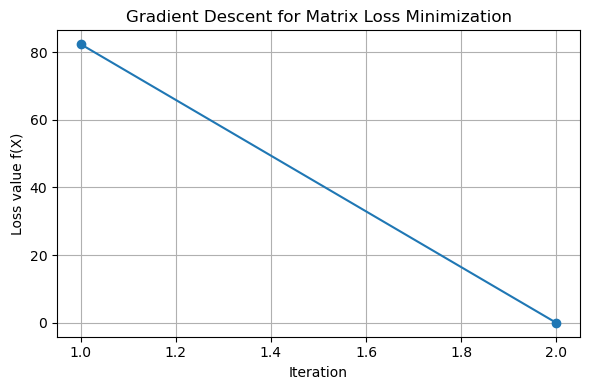

In [9]:
# problem 4
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

#  5). initialize matrices X and A (random initialization) 
m, n = 100, 50       # X ∈ R^{100×50}
np.random.seed(0)    # to ensure reproducibility, you can fix the random seed.

A = np.random.randn(m, n)   # kown A
X0 = np.random.randn(m, n)  # Initial guess X_0

# 1). define the loss function f(X) = 1/2 * Σ (X_ij - A_ij)^2 
def loss(x_flat):
    
    # x_flat : A one-dimensional vector of shape (m*n,) corresponding to the flattened form of matrix X.
    # return: scalar loss value f(X)
    
    X = x_flat.reshape(m, n)
    return 0.5 * np.sum((X - A) ** 2)

# 2). define gradient ∇f(X) = X - A 
def grad(x_flat):
   # return the flattened gradient vector in form (m*n,)
    
    X = x_flat.reshape(m, n)
    g = X - A            # ∇f(X) = X - A
    return g.ravel()     # match scipy.optimize.minimize

# 3 & 4). using scipy.optimize.minimize to implementing Gradient Descent with Early Stopping 

class ConvergenceChecker:
    
    # callback ：
    # record the loss at each step
# determine whether to stop early based on the difference between consecutive loss values
    
    def __init__(self, tol=1e-6, max_iter=1000):
        self.tol = tol
        self.max_iter = max_iter
        self.loss_history = []
        self.x_last = None      # record the x value from the last iteration 

    def __call__(self, xk):
        # record current loss
        fk = loss(xk)
        self.loss_history.append(fk)
        self.x_last = xk.copy()

        # If there have been two or more iterations, check the difference between adjacent loss values.
        if len(self.loss_history) >= 2:
            diff = abs(self.loss_history[-1] - self.loss_history[-2])
            if diff < self.tol:
                print(f"Early stopping at iter {len(self.loss_history)}, "
                      f"|Δloss| = {diff:.2e} < {self.tol}")
                # interrupting minimize by throwing an exception (minimize does not have a built-in “stop” switch)
                raise StopIteration

        # If the number of iterations exceeds the upper limit, stop.
        if len(self.loss_history) >= self.max_iter:
            print(f"Reached maximum iterations: {self.max_iter}")
            raise StopIteration


checker = ConvergenceChecker(tol=1e-6, max_iter=1000)

x0_flat = X0.ravel()

try:
    # Using the conjugate gradient method, explicitly compute the gradient grad.
    res = minimize(
        fun=loss,
        x0=x0_flat,
        jac=grad,
        method='CG',         # gradient-based method
        callback=checker     # each step calls the checker
        # maxiter is not enforced here; early termination is controlled by the checker.
    )
    # If StopIteration is not raised in advance, use res.x as the final result.
    X_opt_flat = res.x
except StopIteration:
    # If we manually stop early, retrieve the last x from the checker.
    X_opt_flat = checker.x_last

X_opt = X_opt_flat.reshape(m, n)
loss_history = checker.loss_history

print("Number of iterations:", len(loss_history))
print("Final loss:", loss_history[-1])
print("Frobenius norm ||X_opt - A||_F:", np.linalg.norm(X_opt - A))

# 6). Plot: Loss vs. Iteration Count 
plt.figure(figsize=(6,4))
plt.plot(range(1, len(loss_history)+1), loss_history, marker='o')
plt.xlabel("Iteration")
plt.ylabel("Loss value f(X)")
plt.title("Gradient Descent for Matrix Loss Minimization")
plt.grid(True)
plt.tight_layout()
plt.show()


In [1]:
# problem 2
import pandas as pd

data = pd.read_csv("data.csv")  
print(data.head())  # Look at the first few lines to confirm that the reading was successful.


     Height    Weight
0  1.764052  1.883151
1  0.400157 -1.347759
2  0.978738 -1.270485
3  2.240893  0.969397
4  1.867558 -1.173123


First few rows of the dataset:
     Height    Weight
0  1.764052  1.883151
1  0.400157 -1.347759
2  0.978738 -1.270485
3  2.240893  0.969397
4  1.867558 -1.173123

Covariance matrix:
[[1.02608749 0.11769063]
 [0.11769063 1.08134929]]

Eigenvalues (largest to smallest):
[1.17460905 0.93282774]

Eigenvectors (columns correspond to eigenvalues):
[[ 0.62106317 -0.78376051]
 [ 0.78376051  0.62106317]]

Explained variance ratio of each principal component:
[0.55736383 0.44263617]


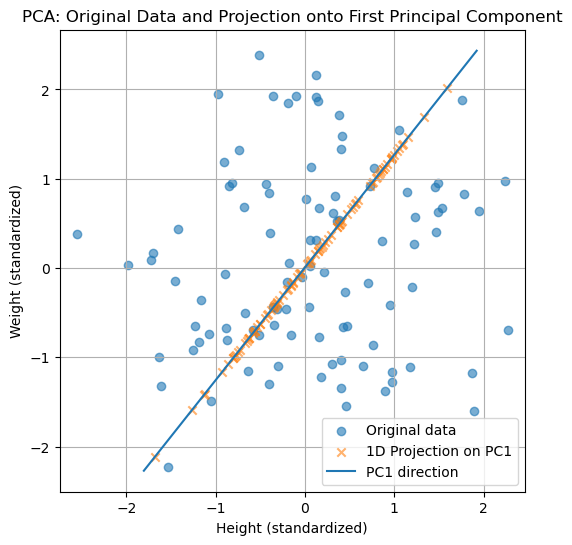

In [3]:
import numpy as np
import pandas as pd
from scipy.linalg import eigh
import matplotlib.pyplot as plt

# fristly: Load CSV data into Jupyter
# make sure the file "data.csv" is uploaded in the same directory as this notebook.
df = pd.read_csv("data.csv")

print("First few rows of the dataset:")
print(df.head())

# assume the first two columns are standardized height and weight
X = df.iloc[:, :2].values   # shape = (100, 2)


# 1) compute the covariance matrix
# even though the data is standardized, we still center it for numerical stability
X_mean = X.mean(axis=0)
X_centered = X - X_mean

# compute 2x2 covariance matrix
cov_matrix = np.cov(X_centered, rowvar=False)

print("\nCovariance matrix:")
print(cov_matrix)

# 2). eigenvalue decomposition using scipy.linalg.eigh
# eigh is used because the covariance matrix is symmetric
eigvals, eigvecs = eigh(cov_matrix)

# sort eigenvalues and eigenvectors in descending order
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

print("\nEigenvalues (largest to smallest):")
print(eigvals)

print("\nEigenvectors (columns correspond to eigenvalues):")
print(eigvecs)

# 3). Identify principal components and variance explained
# first principal component = eigenvector associated with largest eigenvalue
pc1 = eigvecs[:, 0]

# variance explained ratio
explained_variance_ratio = eigvals / eigvals.sum()
print("\nExplained variance ratio of each principal component:")
print(explained_variance_ratio)

# 4). project data onto the first principal component (1D)
# 1D representation: projection onto PC1
X_proj_1d = X_centered @ pc1     # shape = (100,)

# convert 1D projection back into 2D space for visualization
X_proj_2d = np.outer(X_proj_1d, pc1) + X_mean

# plot original data + 1D projection along PC1
plt.figure(figsize=(6, 6))

# plot original data points
plt.scatter(X[:, 0], X[:, 1], alpha=0.6, label="Original data")

# plot projected points
plt.scatter(X_proj_2d[:, 0], X_proj_2d[:, 1], alpha=0.6, marker="x", label="1D Projection on PC1")

# plot the PC1 direction line through the data mean
line_length = 3   # controls how long the PC1 line is
pc1_line = np.vstack([
    X_mean - line_length * pc1,
    X_mean + line_length * pc1
])
plt.plot(pc1_line[:, 0], pc1_line[:, 1], label="PC1 direction")

plt.xlabel("Height (standardized)")
plt.ylabel("Weight (standardized)")
plt.title("PCA: Original Data and Projection onto First Principal Component")
plt.legend()
plt.axis("equal")
plt.grid(True)
plt.show()

